# Customer Churn Analytics & Retention Insights


## Business Problem

Customer churn is a major challenge for subscription-based businesses because losing customers directly impacts revenue and increases customer acquisition costs.

The objective of this project is to analyze customer behavior, identify the key factors associated with churn, and generate business insights that can support customer retention strategies.

## Objectives

- Understand customer churn patterns
- Analyze customer demographics and service usage
- Identify high-risk customer segments
- Support data-driven retention strategies

## Dataset Overview

The dataset contains telecom customer information including demographics, contract details, tenure, internet services, payment methods, monthly charges, total charges, and customer churn status.

In [2]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import os

# Create Reports and Visualizations folders if they don't exist
os.makedirs("../Reports/Visualizations", exist_ok=True)

In [27]:
#Dataset Load
df = pd.read_csv("../Data/churn_data.csv")

In [28]:
#First 5 Rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [29]:
#Dataset Shape
df.shape

(7043, 21)

In [30]:
#Columns
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [31]:
#Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [32]:
df.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [33]:
#Missing Values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [34]:
#duplicate record check
df.duplicated().sum()

np.int64(0)

In [35]:
# Blank values in TotalCharges

(df['TotalCharges'] == ' ').sum()

np.int64(11)

In [36]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [37]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [38]:
df[df['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [39]:
df[df['TotalCharges'].isnull()][['tenure','MonthlyCharges','TotalCharges']]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [40]:
df.dropna(inplace=True)

In [41]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Handling Missing Values

After converting the `TotalCharges` column from text to numeric, 11 missing values were identified.

Further investigation showed that all missing records belonged to customers with **zero tenure**, indicating that these customers had recently joined and had not yet accumulated any charges.

Since only **11 out of 7,043 records (0.16%)** contained missing values, these rows were removed to ensure accurate numerical analysis while having a negligible impact on the overall dataset.

# EDA

In [42]:
#Churn Count
df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

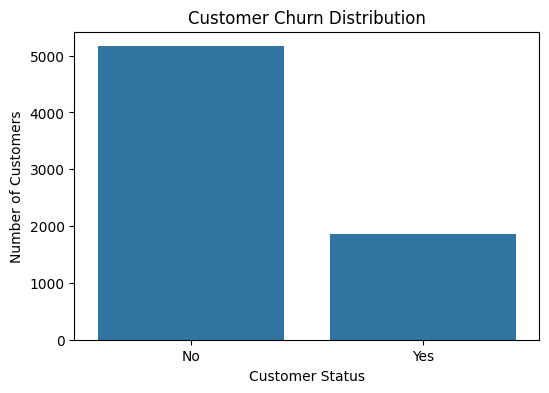

Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64

In [43]:
import os

# Create folder if it doesn't exist
os.makedirs("../Reports/Visualizations", exist_ok=True)

# Customer Churn Distribution

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='Churn'
)

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

# Save Figure
plt.savefig(
    "../Reports/Visualizations/01_Customer_Churn_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Churn Percentage
(df['Churn'].value_counts(normalize=True) * 100).round(2)

## Customer Churn Distribution

### Observation

After data cleaning, the dataset contains **7,032 customers**.

Approximately **73.42%** of customers are retained, while **26.58%** have churned.

### Business Insight

A churn rate of **26.58%** indicates that nearly **one out of every four customers** has left the company. This represents a significant retention challenge and highlights the need to understand the factors influencing customer churn.

### Recommendation

Further analysis should focus on customer segments such as **contract type, tenure, internet service, payment method, and monthly charges** to identify high-risk customers and support targeted retention strategies.

# Which contract type has the highest customer churn?

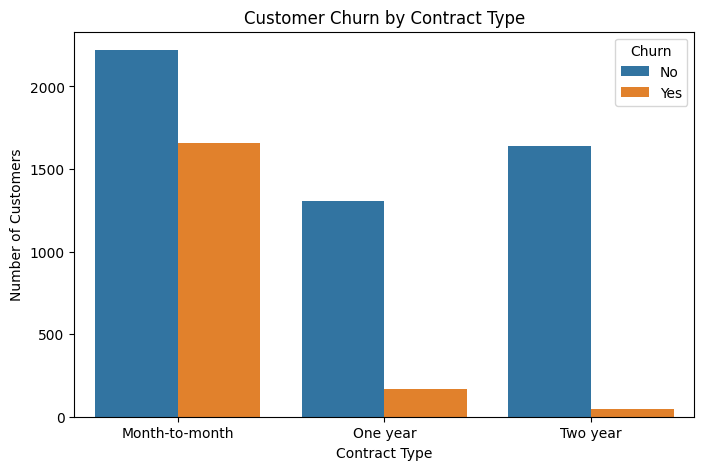

In [44]:
# Contract Type vs Customer Churn

# Contract Type vs Customer Churn

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Contract',
    hue='Churn'
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

# Save Figure
plt.savefig(
    "../Reports/Visualizations/02_Contract_Type_Count.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [45]:
contract_churn = (
    df.groupby('Contract')['Churn']
      .value_counts(normalize=True)
      .mul(100)
      .rename('ChurnRate')
      .reset_index()
)

contract_churn

,Contract,Churn,ChurnRate
0,Month-to-month,No,57.290323
1,Month-to-month,Yes,42.709677
2,One year,No,88.722826
3,One year,Yes,11.277174
4,Two year,No,97.151335
5,Two year,Yes,2.848665


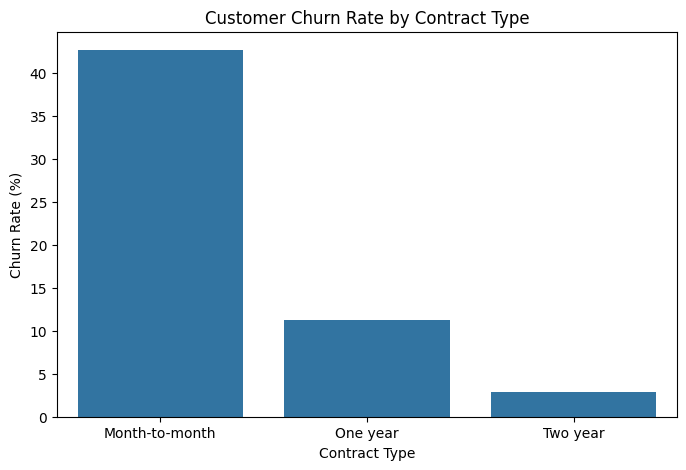

In [46]:
contract_yes = contract_churn[contract_churn['Churn'] == 'Yes']

# Visualization

plt.figure(figsize=(8,5))

sns.barplot(
    data=contract_yes,
    x='Contract',
    y='ChurnRate'
)

plt.title("Customer Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

# Save Figure
plt.savefig(
    "../Reports/Visualizations/03_Contract_Churn_Rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Contract Type vs Customer Churn

### Observation

- Customers with **Month-to-Month** contracts have the highest churn rate (**42.71%**).
- Customers with **One-Year** contracts have a churn rate of **11.28%**.
- Customers with **Two-Year** contracts have the lowest churn rate (**2.85%**).

### Business Insight

Contract type is one of the strongest factors associated with customer churn. Customers on long-term contracts are significantly more likely to stay with the company than customers on month-to-month contracts.

### Recommendation

The business should focus retention campaigns on Month-to-Month customers by offering contract upgrade incentives, loyalty rewards, or bundled service plans to encourage migration to longer-term contracts.

### Key Finding

Increasing adoption of One-Year and Two-Year contracts may help improve customer retention and reduce churn.

## Business Question

Does customer tenure have any relationship with customer churn?

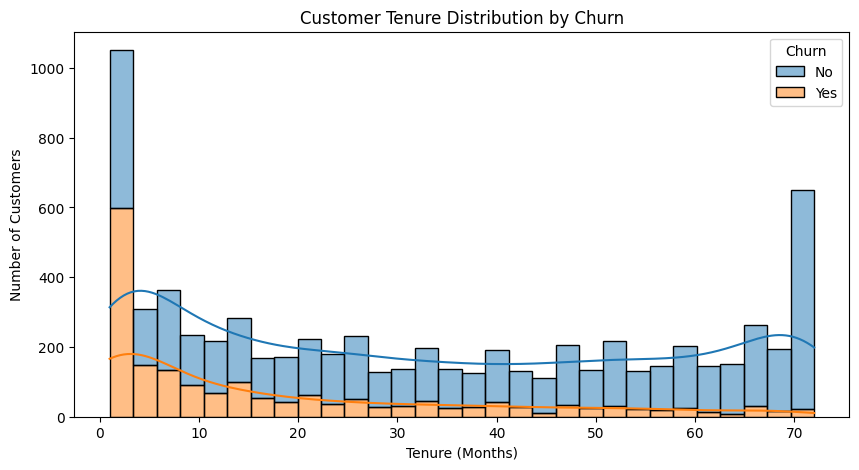

In [47]:
# Tenure Distribution by Customer Churn

plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='tenure',
    hue='Churn',
    bins=30,
    kde=True,
    multiple='stack'
)

plt.title("Customer Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

# Save Figure
plt.savefig(
    "../Reports/Visualizations/04_Tenure_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [48]:
# Average Tenure by Churn Status

tenure_summary = (
    df.groupby('Churn')['tenure']
      .agg(['count','mean','median','min','max'])
      .round(2)
)

tenure_summary

,count,mean,median,min,max
Churn,,,,,
No,5163,37.65,38.0,1,72
Yes,1869,17.98,10.0,1,72


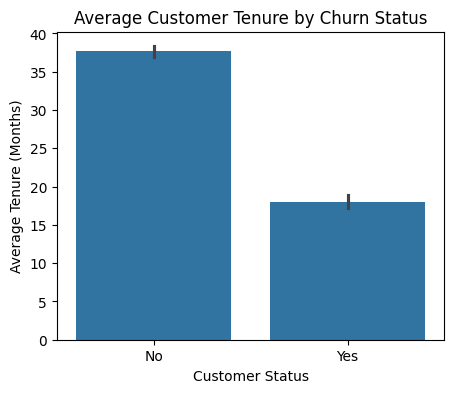

In [49]:
# Average Customer Tenure

plt.figure(figsize=(5,4))

sns.barplot(
    data=df,
    x='Churn',
    y='tenure'
)

plt.title("Average Customer Tenure by Churn Status")
plt.xlabel("Customer Status")
plt.ylabel("Average Tenure (Months)")

# Save Figure
plt.savefig(
    "../Reports/Visualizations/05_Average_Tenure.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Customer Tenure vs Churn

### Observation

- Retained customers have an average tenure of **37.65 months**.
- Churned customers have an average tenure of only **17.98 months**.
- The median tenure for churned customers is **10 months**, indicating that many customers leave relatively early in their lifecycle.

### Business Insight

Customer tenure is strongly associated with customer retention. Customers who remain with the company for a longer period are considerably less likely to churn. Early-stage customers represent the highest-risk segment.

### Recommendation

The business should strengthen customer onboarding, early engagement, and proactive support during the first year of the customer lifecycle. Targeted retention campaigns for low-tenure customers may help reduce churn.

## Business Question

Do customers with higher monthly charges have a higher tendency to churn?

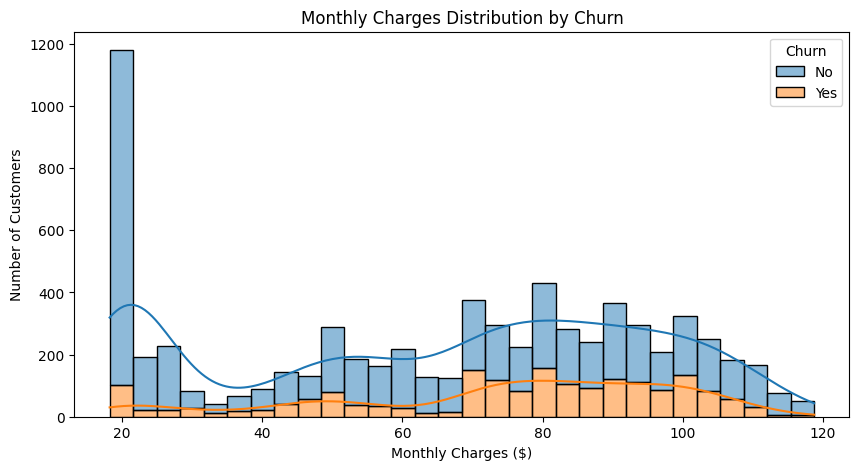

In [50]:
# Monthly Charges Distribution by Customer Churn

plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='MonthlyCharges',
    hue='Churn',
    bins=30,
    kde=True,
    multiple='stack'
)

plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Monthly Charges ($)")
plt.ylabel("Number of Customers")

# Save Figure
plt.savefig(
    "../Reports/Visualizations/06_Monthly_Charges_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [51]:
monthly_summary = (
    df.groupby('Churn')['MonthlyCharges']
      .agg(['count','mean','median','min','max'])
      .round(2)
)

monthly_summary

,count,mean,median,min,max
Churn,,,,,
No,5163,61.31,64.45,18.25,118.75
Yes,1869,74.44,79.65,18.85,118.35


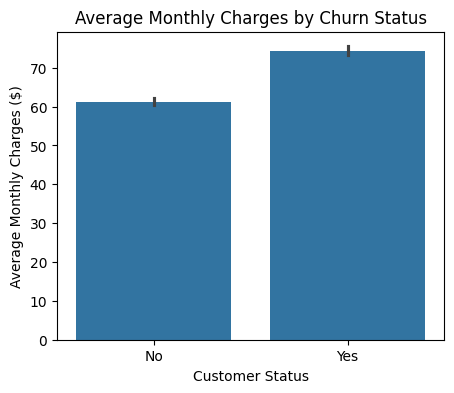

In [52]:
plt.figure(figsize=(5,4))

sns.barplot(
    data=df,
    x='Churn',
    y='MonthlyCharges'
)

plt.title("Average Monthly Charges by Churn Status")
plt.xlabel("Customer Status")
plt.ylabel("Average Monthly Charges ($)")

# Save Figure
plt.savefig(
    "../Reports/Visualizations/07_Average_Monthly_Charges.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Monthly Charges vs Customer Churn

### Observation

- Churned customers have higher average monthly charges than retained customers.
- The distribution shows that customers with higher monthly charges are more likely to churn.

### Business Insight

Monthly charges appear to be associated with customer churn. Customers paying higher monthly fees may have greater expectations regarding service quality and value.

### Recommendation

The business should review pricing strategies for high-paying customers and consider loyalty benefits, personalized offers, or service improvements to improve customer retention.

### Key Finding

Customers with higher monthly charges represent an important segment for proactive retention initiatives.

## Business Question

Which Internet Service category experiences the highest customer churn?

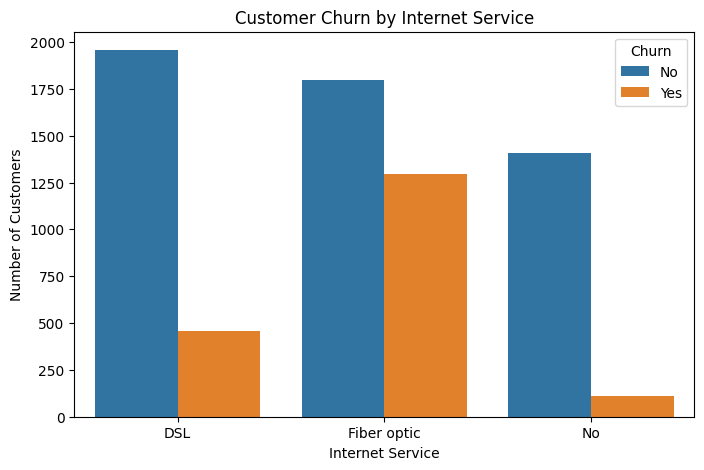

In [53]:
# Customer Churn by Internet Service

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='InternetService',
    hue='Churn'
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

# Save Figure
plt.savefig(
    "../Reports/Visualizations/08_Internet_Service_Count.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [54]:
internet_churn = (
    df.groupby('InternetService')['Churn']
      .value_counts(normalize=True)
      .mul(100)
      .rename('ChurnRate')
      .reset_index()
)

internet_churn

,InternetService,Churn,ChurnRate
0,DSL,No,81.001656
1,DSL,Yes,18.998344
2,Fiber optic,No,58.107235
3,Fiber optic,Yes,41.892765
4,No,No,92.565789
5,No,Yes,7.434211


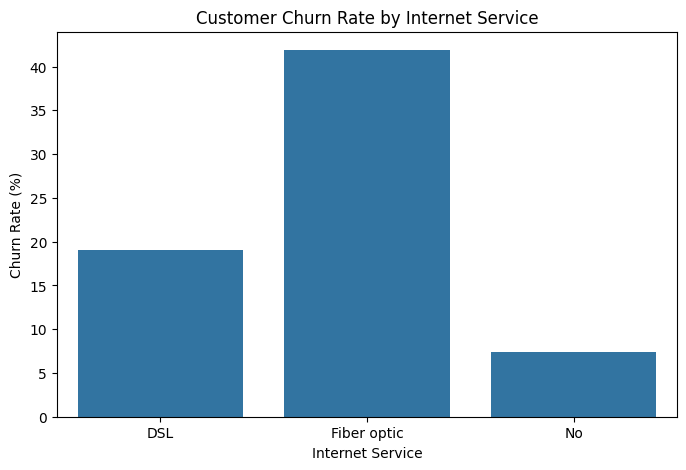

In [55]:
internet_yes = internet_churn[internet_churn['Churn'] == 'Yes']

plt.figure(figsize=(8,5))

sns.barplot(
    data=internet_yes,
    x='InternetService',
    y='ChurnRate'
)

plt.title("Customer Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

# Save Figure
plt.savefig(
    "../Reports/Visualizations/09_Internet_Service_Churn_Rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Internet Service vs Customer Churn

### Observation

- Customers using different internet services show different churn patterns.
- The churn rate varies across Fiber optic, DSL, and customers without internet service.

### Business Insight

Internet service type appears to be associated with customer churn. Service quality, pricing, customer expectations, and support experience may influence retention across different service categories.

### Recommendation

The company should closely monitor the internet service segment with the highest churn rate and investigate factors such as pricing, service quality, network reliability, and customer support.

### Key Finding

Internet service is an important customer segmentation variable for identifying customers at higher risk of churn.

## Business Question

Does the customer's payment method have any relationship with customer churn?

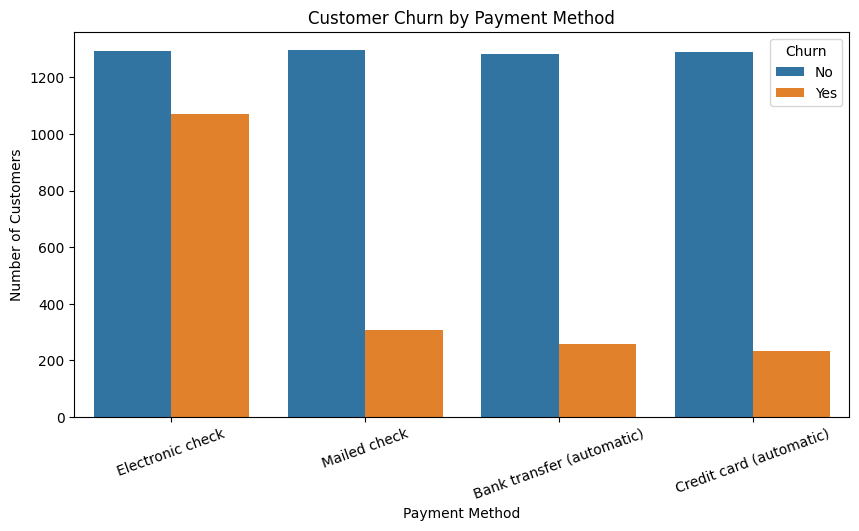

In [56]:
# Customer Churn by Payment Method

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='PaymentMethod',
    hue='Churn'
)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.legend(title="Churn")

# Save Figure
plt.savefig(
    "../Reports/Visualizations/10_Payment_Method_Count.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [57]:
payment_churn = (
    df.groupby('PaymentMethod')['Churn']
      .value_counts(normalize=True)
      .mul(100)
      .rename('ChurnRate')
      .reset_index()
)

payment_churn

,PaymentMethod,Churn,ChurnRate
0,Bank transfer (automatic),No,83.268482
1,Bank transfer (automatic),Yes,16.731518
2,Credit card (automatic),No,84.746877
3,Credit card (automatic),Yes,15.253123
4,Electronic check,No,54.714588
5,Electronic check,Yes,45.285412
6,Mailed check,No,80.798005
7,Mailed check,Yes,19.201995


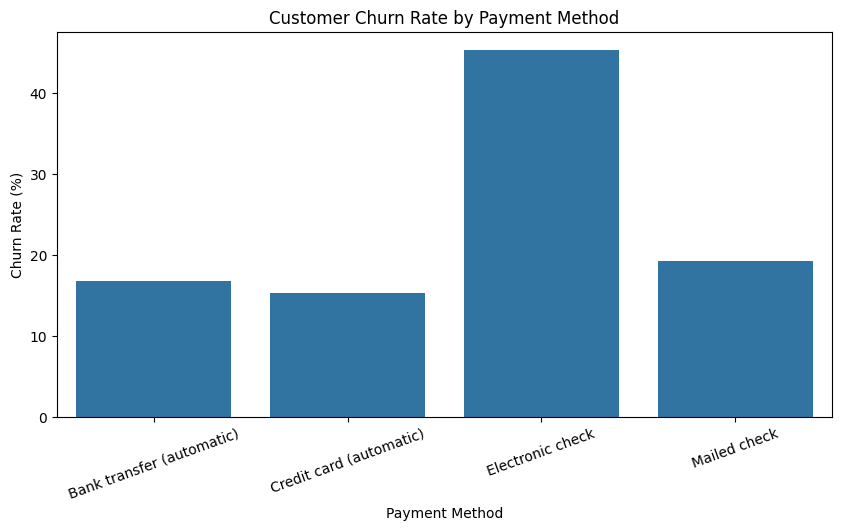

In [58]:
payment_yes = payment_churn[payment_churn['Churn']=="Yes"]

plt.figure(figsize=(10,5))

sns.barplot(
    data=payment_yes,
    x='PaymentMethod',
    y='ChurnRate'
)

plt.title("Customer Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=20)

# Save Figure
plt.savefig(
    "../Reports/Visualizations/11_Payment_Method_Churn_Rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Payment Method vs Customer Churn

### Observation

- Customer churn varies across different payment methods.
- Some payment methods show noticeably higher churn rates than others.

### Business Insight

Payment behavior appears to be associated with customer churn. Differences may reflect customer preferences, convenience, billing experience, or the type of customers using each payment method.

### Recommendation

The company should investigate payment methods with higher churn rates and evaluate whether improvements in billing experience, payment flexibility, or customer communication could improve retention.

### Key Finding

Payment method is a useful customer segmentation variable for identifying customers at higher risk of churn.

## Business Question

Do senior citizens have a different customer churn pattern compared with non-senior customers?

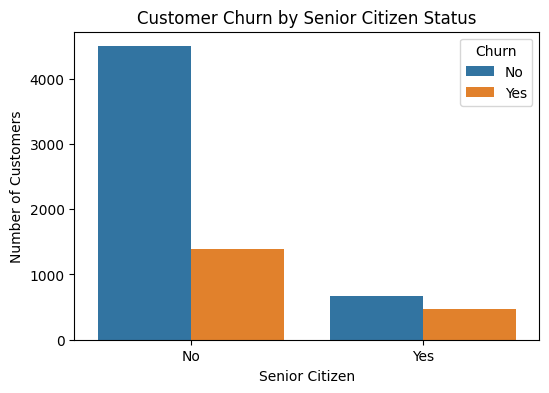

In [59]:
# Customer Churn by Senior Citizen

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='SeniorCitizen',
    hue='Churn'
)

plt.title("Customer Churn by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")

plt.xticks([0,1],["No","Yes"])

plt.legend(title="Churn")

# Save Figure
plt.savefig(
    "../Reports/Visualizations/12_Senior_Citizen.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Senior Citizen vs Customer Churn

### Observation

The churn distribution differs between senior citizens and non-senior customers.

### Business Insight

Customer age group may influence churn behaviour and should be considered together with other customer characteristics such as tenure, contract type, and monthly charges.

### Recommendation

If senior citizens demonstrate higher churn rates, the company should evaluate whether tailored customer support, simplified service plans, or personalized communication could improve retention.

## Business Question

Does customer gender significantly affect customer churn?

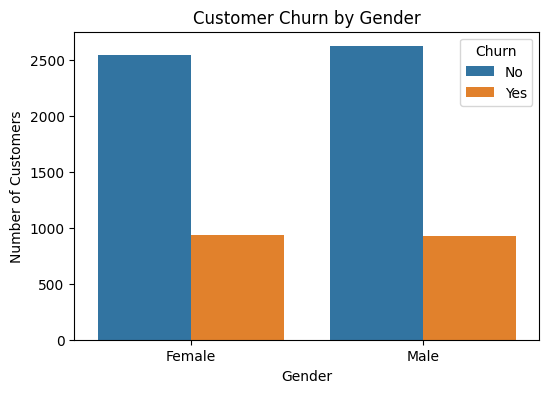

In [60]:
# Customer Churn by Gender

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='gender',
    hue='Churn'
)

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.legend(title="Churn")

# Save Figure
plt.savefig(
    "../Reports/Visualizations/13_Gender.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Gender vs Customer Churn

### Observation

Customer churn appears relatively similar across male and female customers.

### Business Insight

Gender alone does not appear to be a strong indicator of customer churn. Business factors such as contract type, tenure, internet service, and monthly charges provide stronger explanatory value.

### Recommendation

The business should prioritize behavioural and service-related variables over gender when developing customer retention strategies.

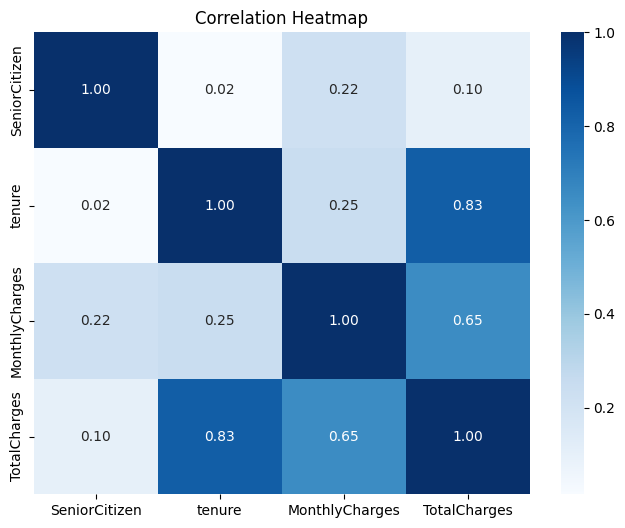

In [61]:
# Correlation Heatmap

numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

# Save Figure
plt.savefig(
    "../Reports/Visualizations/14_Correlation_Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Correlation Analysis

### Observation

The heatmap illustrates the relationships among the numeric variables in the dataset.

### Business Insight

Correlation analysis helps identify variables that move together and provides additional context before building predictive models or conducting more advanced analyses.

### Recommendation

Correlation should be interpreted alongside business understanding because it indicates association rather than causation.

# Key Business Findings

Based on the exploratory analysis, the following business findings were identified:

1. Customer churn rate is **26.58%**, indicating that approximately one out of every four customers has left the company.

2. Customers with **Month-to-Month contracts** have the highest churn rate, making contract type one of the strongest indicators of customer retention.

3. Customers with **lower tenure** are significantly more likely to churn than long-term customers, highlighting the importance of early customer engagement.

4. Customers with **higher monthly charges** tend to churn more frequently, suggesting that pricing and perceived value may influence retention.

5. Customer churn differs across **Internet Service** categories, indicating that service quality and customer experience should be evaluated further.

6. Customer churn also varies across **Payment Methods**, suggesting that billing experience may contribute to customer retention.

7. **Gender** does not appear to be a strong indicator of customer churn compared with behavioural and service-related variables.

8. Demographic characteristics such as **Senior Citizen** status should be considered together with business variables rather than independently.

# Business Recommendations

Based on the analysis, the following recommendations are suggested:

### 1. Improve Month-to-Month Customer Retention

Develop targeted retention campaigns for Month-to-Month customers by offering contract upgrade incentives, loyalty rewards, and bundled service plans.

### 2. Strengthen Customer Onboarding

Customers with lower tenure should receive proactive onboarding support, welcome offers, and regular engagement during the early months of their customer lifecycle.

### 3. Review Pricing Strategy

Evaluate whether customers paying higher monthly charges perceive sufficient value from the services provided.

### 4. Improve Internet Service Experience

Investigate service quality, pricing, and customer support for internet service categories with higher churn rates.

### 5. Enhance Billing Experience

Review payment methods associated with higher churn and simplify billing processes where appropriate.

### 6. Prioritize Behaviour-Based Segmentation

Customer retention strategies should focus primarily on behavioural indicators such as contract type, tenure, monthly charges, and service usage rather than demographic characteristics alone.

# Conclusion

This project analyzed customer churn using Python, SQL, and Power BI to identify customer segments associated with higher churn risk.

The analysis demonstrated that contract type, customer tenure, monthly charges, internet service, and payment method were the strongest factors associated with customer churn.

The findings can support business stakeholders in designing targeted customer retention strategies, improving customer experience, and reducing customer churn through data-driven decision-making.

This project demonstrates practical skills in data cleaning, exploratory data analysis, SQL analytics, business reporting, and data visualization using Power BI.

In [62]:
# High-risk churn segments
risk_summary = df.groupby(['Contract', 'InternetService'])['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(1)

print(risk_summary)

Contract        InternetService
Month-to-month  DSL                32.2
                Fiber optic        54.6
                No                 18.9
One year        DSL                 9.3
                Fiber optic        19.3
                No                  2.5
Two year        DSL                 1.9
                Fiber optic         7.2
                No                  0.8
Name: Churn, dtype: float64
